In [1]:
from pathlib import Path
import numpy as np

from feature import (
    make_stft_extractor
)

from testing import(
    load_model_config,
    load_all_template_features_new,
    load_raven_selection_table,
    get_exclusion_intervals,
    detection_pipeline,
    merge_consecutive_detections,
    match_detections,
    compute_pr_curve_alpha,
    compute_average_precision,
    plot_pr_curve,
    plot_detection_spectrograms
)

In [2]:
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")

DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\22")

In [3]:
#editable variables
feat_method = "stft"
n_temps = 5
step_frac = 0.75
min_windows = 1
max_call_length = 3.0
max_window_gap = 2

In [4]:
#download relevent calibration info
cfg = load_model_config(RESULTS / f"model_config_{feat_method}_{n_temps}.json")

feat_method_test = cfg["feature"]["method"]
fs_new = cfg["feature"]["fs_new"]
feat_frame_length = cfg["feature"]["frame_len"]
dtw_method = cfg["dtw_method"]
window_length = cfg["window_len"]
vote_frac = cfg["best_vote_frac"]
n_temps_test = cfg["n_temps"]
n_calib = cfg["n_calib"]

call_thresholds = cfg["thresholds"]      # {"st": ..., "mt": ..., "bt": ...}
st_threshold = call_thresholds["st"]
mt_threshold = call_thresholds["mt"]
bt_threshold = call_thresholds["bt"]

# Template files used during calibration
# st_temp_file = cfg["template_files"]["st"]
# mt_temp_file = cfg["template_files"]["mt"]
# bt_temp_file = cfg["template_files"]["bt"]

# Rebuild the extractor exactly as it was during calibration
if feat_method == "stft":
    extractor = make_stft_extractor(frame_dur=feat_frame_length)

step_length = round(window_length * step_frac,3)
print(step_length)

if feat_method_test == feat_method and n_temps_test == n_temps:
    print("Passed download test")

print(f"{feat_method_test}, fs_new = {fs_new}, frame len = {feat_frame_length}, win len = {window_length}, vote frac = {vote_frac}, n_temps = {n_temps_test}, n_calib = {n_calib}")
print(f"st: {st_threshold}, mt: {mt_threshold}, bt: {bt_threshold}")
print(f"dtw method: {dtw_method}")

0.375
Passed download test
stft, fs_new = 1000, frame len = 0.048, win len = 0.5, vote frac = 0.2, n_temps = 5, n_calib = 10
st: 0.09737246168327404, mt: 0.1148767153571217, bt: 0.09904819932465697
dtw method: old


In [5]:
max_windows = int(round(max_call_length / window_length, 0))
print(max_windows)

6


In [6]:
st_feats, mt_feats, bt_feats = load_all_template_features_new(
    results_dir=RESULTS_29,
    file_label="20230429_Templates",
    recording_label="20230429_102841",
    extractor=extractor,
    n_temps=n_temps,
    fs_new=fs_new,
)

In [7]:
raven_table = load_raven_selection_table(DATA_22 / "2023-04-22T17-13-01_000_00070.txt")
td_intervals = get_exclusion_intervals(raven_table, exclude_labels=("td",), pad=0.1)

In [8]:
#all_kth
all_detected_t, all_detected_labels, all_times_all, all_kth = detection_pipeline(
    audio_file=DATA_22 / "20230422_171301.wav",
    n_hours=72,
    st_feats=st_feats, mt_feats=mt_feats, bt_feats=bt_feats,
    st_threshold=st_threshold, mt_threshold=mt_threshold, bt_threshold=bt_threshold,
    exclude_intervals=td_intervals,
    extractor=extractor, 
    fs_new=fs_new, window_len=window_length, step_len = step_length, vote_frac= vote_frac,
    dtw_method=dtw_method
)

Processing hour 1 of 72: 9 / 9599 windows flagged as calls
Processing hour 2 of 72: 2 / 9599 windows flagged as calls
Processing hour 3 of 72: 3 / 9599 windows flagged as calls
Processing hour 4 of 72: 1 / 9599 windows flagged as calls
Processing hour 5 of 72: 2 / 9599 windows flagged as calls
Processing hour 6 of 72: 1 / 9599 windows flagged as calls
Processing hour 7 of 72: 3 / 9599 windows flagged as calls
Processing hour 8 of 72: 1 / 9599 windows flagged as calls
Processing hour 9 of 72: 0 / 9599 windows flagged as calls
Processing hour 10 of 72: 4 / 9599 windows flagged as calls
Processing hour 11 of 72: 1 / 9599 windows flagged as calls
Processing hour 12 of 72: 1 / 9599 windows flagged as calls
Processing hour 13 of 72: 0 / 9599 windows flagged as calls
Processing hour 14 of 72: 3 / 9599 windows flagged as calls
Processing hour 15 of 72: 5 / 9599 windows flagged as calls
Processing hour 16 of 72: 1 / 9599 windows flagged as calls
Processing hour 17 of 72: 3 / 9599 windows flagge

In [9]:
calls = merge_consecutive_detections(
    all_detected_t, 
    all_detected_labels,
    step=step_length, 
    window_len=window_length,
    max_gap_windows = max_window_gap,
    min_windows = min_windows,
    max_windows = max_windows
)
print(f"merged {len(all_detected_t)} calls into {len(calls)} calls")

merged 32243 calls into 13713 calls


In [10]:

raven_table_no_td = [g for g in raven_table if g["label"] not in ("td",)]

tp, fp, fn, false_pos, false_neg = match_detections(
    calls,
    raven_table_no_td, 
)

print(f"deployed: calls={len(calls)}  P={tp/(tp+fp):.3f}  R={tp/(tp+fn):.3f}")

deployed: calls=13713  P=0.098  R=0.818


In [11]:
#kth column sanity check before printing PR curve
threshold = (st_threshold, mt_threshold, bt_threshold)
best_ratio = (all_kth / np.array(threshold)).min(axis=1)
print("sanity was k chosen correctly:", (best_ratio < 1).sum(), len(all_detected_t))

sanity was k chosen correctly: 32243 32243


In [12]:
frac = len(all_detected_t) / len(all_times_all)
qs = np.quantile(
    best_ratio[
        np.isfinite(best_ratio)], 
        np.geomspace(1e-4, min(0.5, 5 * frac), 60))

alphas = np.unique(np.append(qs, [1.0, 2.0, 3.0]))

alpha=1: P=0.986  R=0.042   (should be close to the deployed line above)


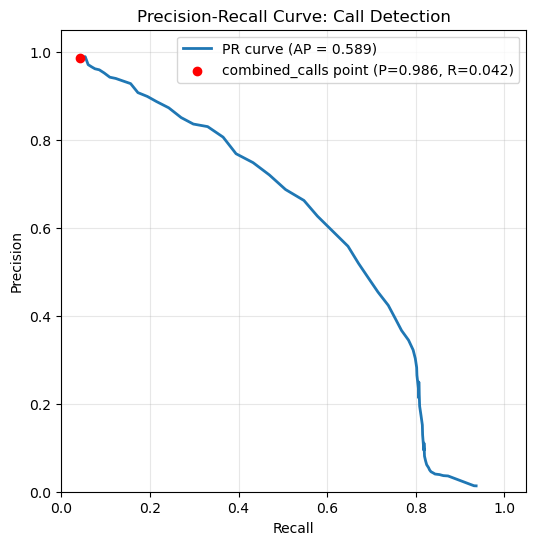

In [13]:
p1, r1, _, _ = compute_pr_curve_alpha(
    all_times_all, 
    all_kth, 
    threshold, 
    raven_table_no_td,
    step=step_length, 
    window_len=window_length, 
    alphas=alphas,
    max_gap_windows = max_window_gap,
    min_windows = min_windows,
    max_windows = max_windows
)
print(f"alpha=1: P={p1[0]:.3f}  R={r1[0]:.3f}   (should be close to the deployed line above)")

ap = compute_average_precision(p1, r1)

plot_pr_curve(p1, r1, ap=ap, marked_point=(p1[0], r1[0]))

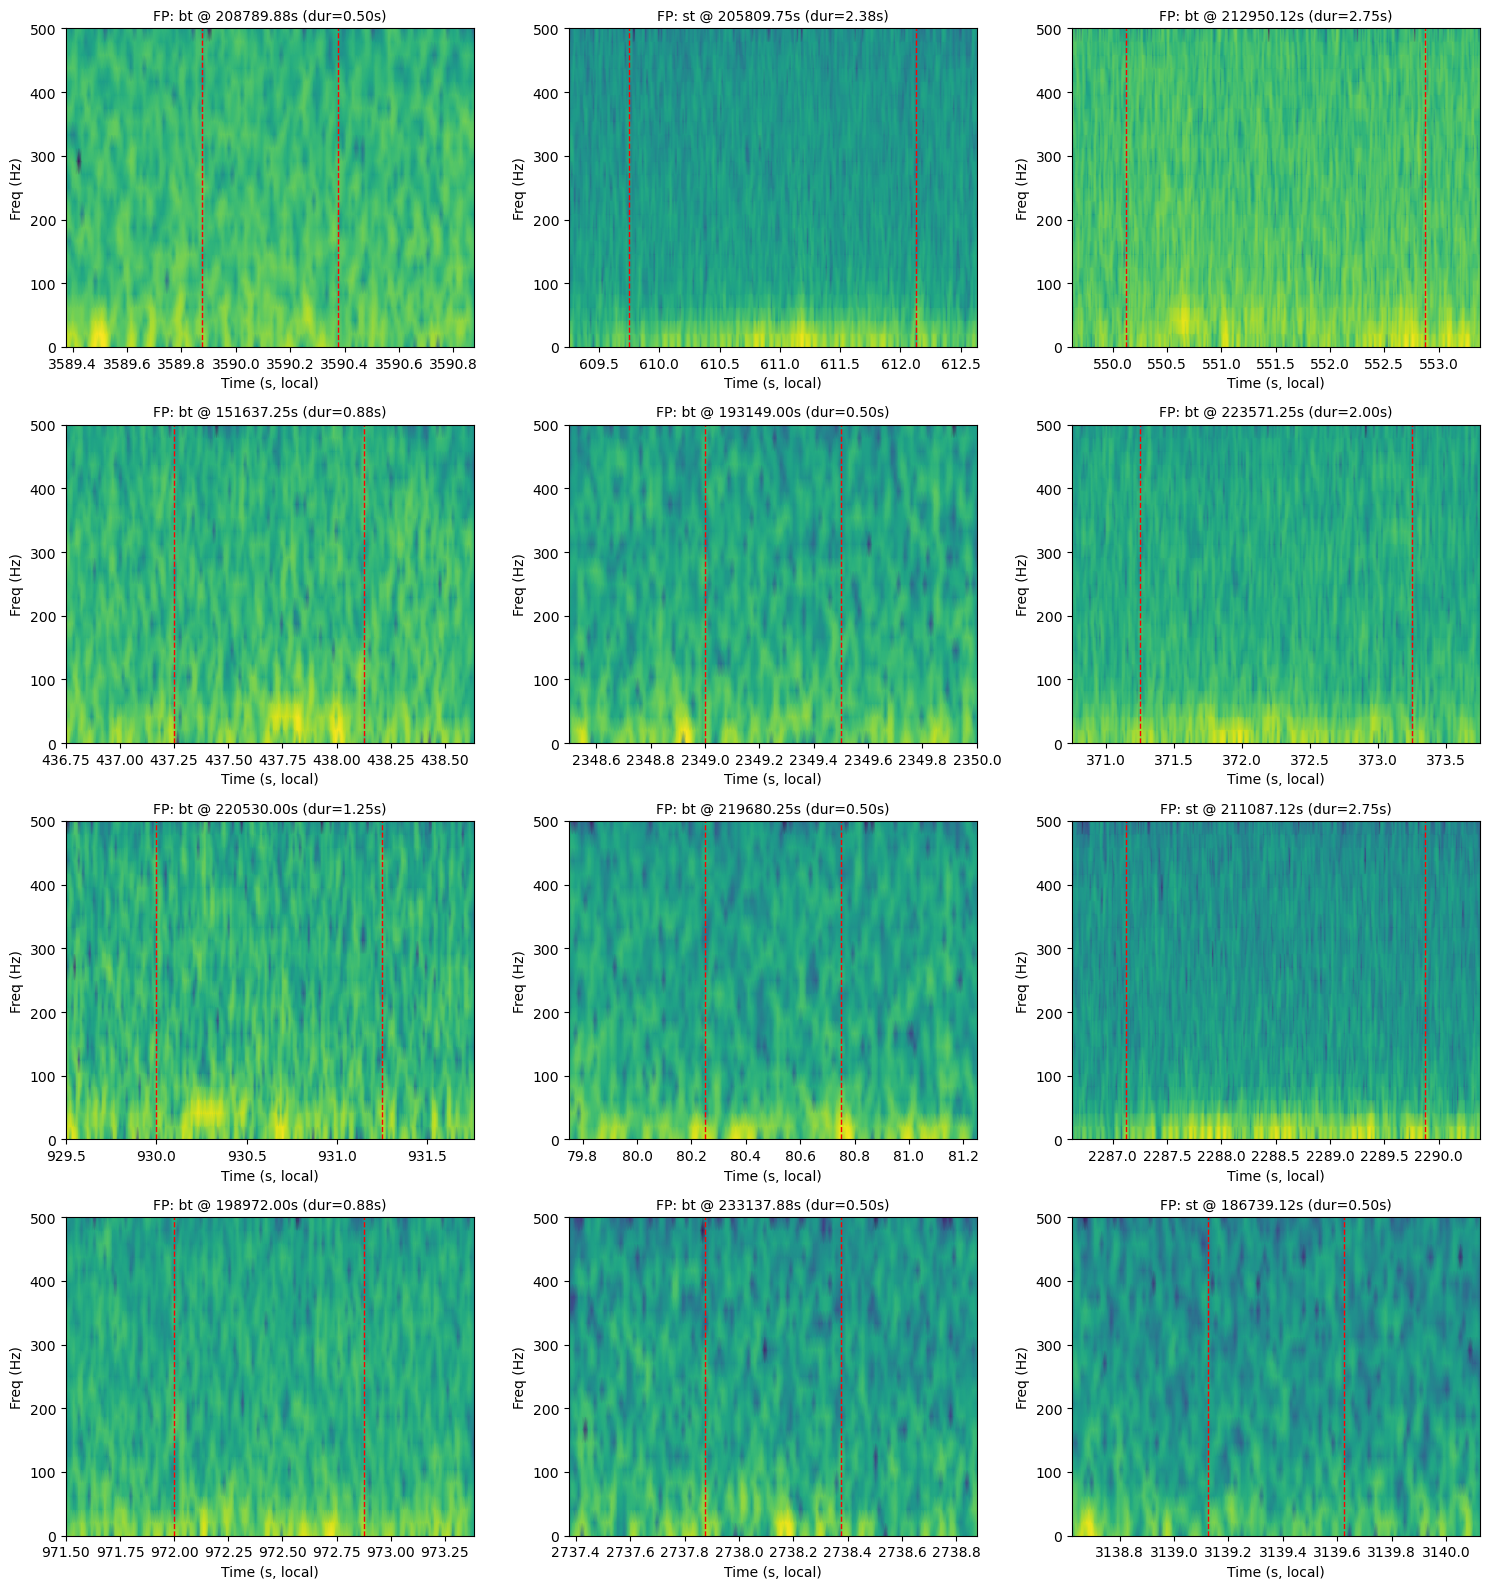

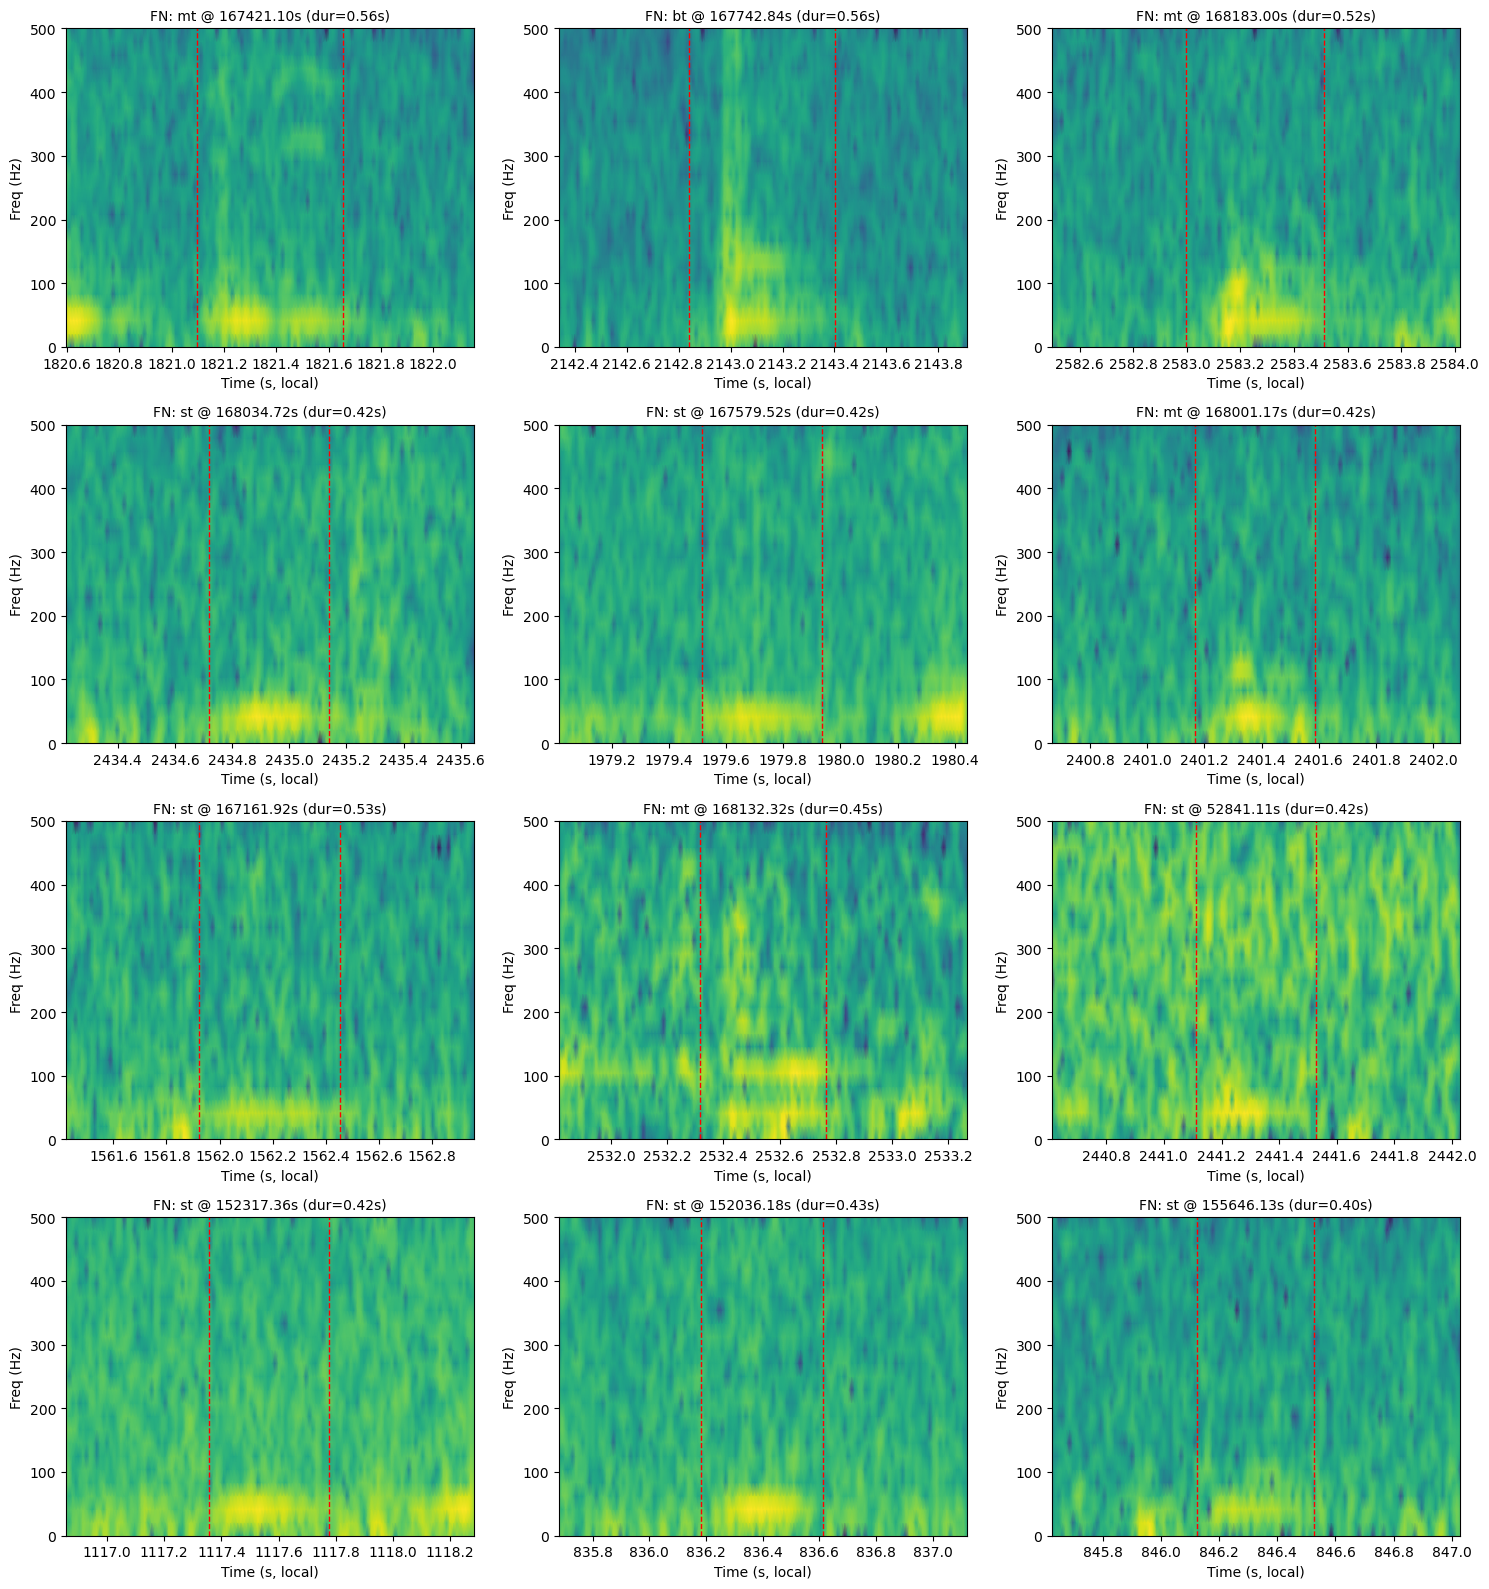

In [14]:
plot_detection_spectrograms(
    false_pos,
    DATA_22 / "20230422_171301.wav",
    fs_new=fs_new,
    framelength=int(fs_new * feat_frame_length),
    n_examples=12,
    title_prefix="FP",
)

fn_as_tuples = [(g["start"], g["end"], g["label"]) for g in false_neg]
plot_detection_spectrograms(
    fn_as_tuples,
    DATA_22 / "20230422_171301.wav",
    fs_new=fs_new,
    framelength=int(fs_new * feat_frame_length),
    n_examples=12,
    title_prefix="FN",
)